# Demonstração de Aprendizado de Máquina (Machine Learning)

Este notebook serve como um guia prático e didático para demonstrar as principais técnicas de Aprendizado de Máquina:

1.  **Classificação**: Prever uma categoria ou classe.
2.  **Regressão**: Prever um valor contínuo.
3.  **Agrupamento (Clustering)**: Identificar estruturas ou grupos em dados não rotulados.

Para cada técnica, abordaremos sua teoria, exemplos práticos utilizando datasets comuns e a implementação em Python com a biblioteca `scikit-learn`.

## 1. Configuração e Importação de Bibliotecas

In [1]:
# Importando as bibliotecas essenciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações para melhor visualização dos gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. **Classificação**

### O que é Classificação?

A Classificação é uma técnica de aprendizado supervisionado onde o objetivo é prever uma categoria ou classe discreta para novas observações. Exemplos comuns incluem: identificar se um e-mail é spam ou não, diagnosticar uma doença (sim/não), ou reconhecer um tipo de flor. Os algoritmos de classificação aprendem com um conjunto de dados rotulado (onde as classes já são conhecidas) para fazer previsões em dados não vistos.

### Exemplo Prático: Classificação de Flores Iris

Vamos usar o famoso dataset Iris, que contém medidas de pétalas e sépalas de três espécies diferentes de flores Iris. Nosso objetivo será classificar a espécie da flor com base nessas medidas.

#### Carregando o Dataset Iris

In [17]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Carregar o dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

#Conferir tamanho total do df
print(f"\nTamanho total do dataset Iris: {iris_df.shape[0]} amostras")

# Convertendo para DataFrame para melhor visualização (opcional)
iris_df = pd.DataFrame(data=X, columns=iris.feature_names)
iris_df['species'] = iris.target_names[y]

print("\nPrimeiras 5 linhas do dataset Iris:")
display(iris_df.head())

#Verificar total por categoria 'species'
print("\nTotal por categoria 'species':")
print(iris_df['species'].value_counts())

print("\nClasses do dataset Iris:")
print(iris.target_names)

print("\nDistribuição das classes:")
print(pd.Series(y).value_counts())


Tamanho total do dataset Iris: 150 amostras

Primeiras 5 linhas do dataset Iris:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Total por categoria 'species':
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Classes do dataset Iris:
['setosa' 'versicolor' 'virginica']

Distribuição das classes:
0    50
1    50
2    50
Name: count, dtype: int64


#### Pré-processamento e Divisão dos Dados

Antes de treinar o modelo, é fundamental dividir os dados em conjuntos de treino e teste. O conjunto de treino é usado para ensinar o modelo, e o conjunto de teste é usado para avaliar seu desempenho em dados não vistos, garantindo que o modelo generalize bem.

### Entendendo os parâmetros de `train_test_split`

A função `train_test_split` do `scikit-learn` é fundamental para dividir seu dataset em conjuntos de treino e teste de forma adequada. Vamos detalhar seus parâmetros:

*   **`X`**: São as **variáveis independentes** (features) do seu dataset. É o que o modelo usará como entrada para fazer previsões. Neste caso, `X` são as medidas de pétalas e sépalas da flor Iris.
*   **`y`**: É a **variável dependente** (rótulo ou alvo) do seu dataset. É o que o modelo está tentando prever. No exemplo da Iris, `y` é a espécie da flor (0, 1 ou 2).
*   **`test_size`**: Define a proporção do dataset que será usada para o conjunto de teste. Um valor de `0.3` (ou 30%) significa que 30% dos dados serão alocados para o teste e os 70% restantes para o treino.
*   **`random_state`**: Este parâmetro controla o *seed* do gerador de números aleatórios usado para embaralhar os dados antes da divisão. Definir um valor fixo (como `42`) garante que a divisão dos dados seja sempre a mesma a cada execução do código. Isso é crucial para **reprodutibilidade**, ou seja, para que você ou outras pessoas obtenham os mesmos resultados ao rodar o notebook.
*   **`stratify`**: Este é um parâmetro muito importante, especialmente em problemas de classificação com classes desbalanceadas. Quando `stratify=y` é usado, a função garante que a proporção de classes (espécies de Iris, neste caso) seja a mesma nos conjuntos de treino e teste. Por exemplo, se 33% do seu dataset original é da classe 'setosa', então tanto o conjunto de treino quanto o de teste terão aproximadamente 33% de amostras 'setosa'. Isso evita que um dos conjuntos tenha uma representação desproporcional de alguma classe, o que poderia levar a um modelo enviesado.

In [18]:
# Dividir os dados em conjuntos de treino e teste
# Confira o texto falando sobre a necessidade dessas variáveis no próximo bloco.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")

print("\nDistribuição das classes no conjunto de treino:")
print(pd.Series(y_train).value_counts())

print("\nDistribuição das classes no conjunto de teste:")
print(pd.Series(y_test).value_counts())

Tamanho do conjunto de treino: 105 amostras
Tamanho do conjunto de teste: 45 amostras

Distribuição das classes no conjunto de treino:
1    35
0    35
2    35
Name: count, dtype: int64

Distribuição das classes no conjunto de teste:
2    15
1    15
0    15
Name: count, dtype: int64


### Por que dividir os dados em `X_train`, `X_test`, `y_train`, `y_test`?

Dividir o dataset nesses quatro conjuntos é uma prática padrão e crucial no aprendizado de máquina por várias razões:

*   **`X_train` (Variáveis Independentes de Treino)**: Contém as features (características) do seu dataset que serão usadas para treinar o modelo. O modelo aprende os padrões e relações a partir desses dados.
*   **`y_train` (Variável Dependente de Treino)**: Contém os rótulos ou valores alvo correspondentes a `X_train`. O modelo usa esses rótulos para aprender a fazer previsões.
*   **`X_test` (Variáveis Independentes de Teste)**: Contém as features que o modelo **nunca viu** durante o treinamento. É usado para simular como o modelo se comportaria com dados novos e desconhecidos.
*   **`y_test` (Variável Dependente de Teste)**: Contém os rótulos ou valores alvo correspondentes a `X_test`. É usado para comparar as previsões do modelo com os valores reais e avaliar seu desempenho.

**Principais razões para essa divisão:**

1.  **Avaliação Justa do Modelo**: Se treinássemos e avaliássemos o modelo com os mesmos dados, ele poderia simplesmente memorizar as respostas (overfitting) e ter um desempenho ruim em dados novos. Usar um conjunto de teste separado garante uma avaliação imparcial da capacidade de generalização do modelo.
2.  **Generalização**: Queremos que nosso modelo aprenda padrões que se apliquem a dados que ele ainda não encontrou. A divisão ajuda a verificar se o modelo é capaz de generalizar bem, ou seja, de fazer previsões precisas em dados do mundo real.
3.  **Detecção de Overfitting**: Um modelo com alto desempenho no conjunto de treino, mas baixo desempenho no conjunto de teste, é um forte indicador de overfitting. A divisão nos permite identificar e mitigar esse problema.

#### Treinamento do Modelo de Classificação (Regressão Logística)

Vamos usar a Regressão Logística, um algoritmo amplamente utilizado para problemas de classificação binária e multiclasse.

In [19]:
# Criar e treinar o modelo de Regressão Logística
# max_iter aumentado para garantir convergência
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train, y_train)

print("Modelo de Regressão Logística treinado com sucesso!")

Modelo de Regressão Logística treinado com sucesso!


#### Avaliação do Modelo

Após o treinamento, avaliamos o desempenho do modelo usando métricas como acurácia, relatório de classificação (precisão, recall, f1-score) e matriz de confusão.

Acurácia do modelo: 0.9333

Relatório de Classificação:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45


Matriz de Confusão:



,setosa,versicolor,virginica
setosa,15,0,0
versicolor,0,14,1
virginica,0,2,13


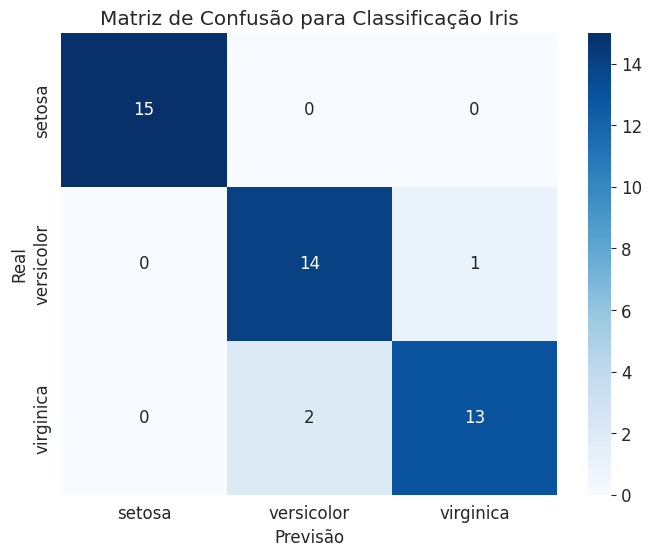

In [20]:
# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

# Avaliar o desempenho do modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=iris.target_names)
conf_mat = confusion_matrix(y_test, y_pred)

print(f"Acurácia do modelo: {accuracy:.4f}")
print("\nRelatório de Classificação:\n")
print(report)

print("\nMatriz de Confusão:\n")
display(pd.DataFrame(conf_mat, index=iris.target_names, columns=iris.target_names))

# Visualização da Matriz de Confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão para Classificação Iris')
plt.show()

### O que é uma Matriz de Confusão para Classificação Iris?

A Matriz de Confusão é uma ferramenta essencial para avaliar o desempenho de um modelo de classificação. Ela fornece uma visualização clara de como o modelo classifica as diferentes classes.

Para o nosso exemplo de classificação Iris, a matriz de confusão possui:

*   **Linhas**: Representam as **classes reais** (os valores `y_test` que são a espécie verdadeira da flor).
*   **Colunas**: Representam as **classes preditas** (os valores `y_pred` que o modelo previu).

**Como interpretar a Matriz de Confusão acima:**

*   **Diagonal Principal (da esquerda superior para a direita inferior)**: Os números nesta diagonal representam as **previsões corretas**. Por exemplo:
    *   `15` na posição (Setosa, Setosa) significa que 15 flores 'Setosa' foram corretamente classificadas como 'Setosa'.
    *   `14` na posição (Versicolor, Versicolor) significa que 14 flores 'Versicolor' foram corretamente classificadas como 'Versicolor'.
    *   `13` na posição (Virginica, Virginica) significa que 13 flores 'Virginica' foram corretamente classificadas como 'Virginica'.

*   **Fora da Diagonal Principal**: Os números fora da diagonal representam as **previsões incorretas** (erros de classificação). Por exemplo:
    *   `1` na posição (Versicolor, Virginica) significa que 1 flor 'Versicolor' real foi erroneamente classificada como 'Virginica'.
    *   `2` na posição (Virginica, Versicolor) significa que 2 flores 'Virginica' reais foram erroneamente classificadas como 'Versicolor'.

Em resumo, a matriz nos permite ver não apenas quantos itens foram classificados corretamente, mas também onde o modelo está errando e quais classes ele tende a confundir.

### 2.1 Outros Algoritmos de Classificação

Além da Regressão Logística, existem muitos outros algoritmos poderosos para classificação, como:

*   **Árvores de Decisão (Decision Trees)**
*   **Random Forest**
*   **Máquinas de Vetores de Suporte (Support Vector Machines - SVM)**
*   **K-Vizinhos Mais Próximos (K-Nearest Neighbors - KNN)**
*   **Redes Neurais (Neural Networks)**

## 3. **Regressão**

### O que é Regressão?

A Regressão é outra técnica de aprendizado supervisionado, mas, ao contrário da classificação, seu objetivo é prever um valor de saída contínuo (numérico). Exemplos incluem: prever o preço de uma casa, a temperatura do próximo dia, ou as vendas futuras de um produto. Os modelos de regressão aprendem a relação entre as variáveis de entrada (features) e a variável de saída contínua a partir de dados históricos rotulados.

### Exemplo Prático: Previsão de Preços de Casas (Dataset Boston Housing modificado)

Como o dataset original de Boston Housing foi removido devido a preocupações éticas, usaremos um dataset sintético ou o dataset California Housing, que é mais adequado para demonstração de regressão. Vamos usar o dataset California Housing para prever o valor médio das casas em distritos da Califórnia.

#### Carregando o Dataset California Housing

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Carregar o dataset California Housing
housing = fetch_california_housing()
X_reg = housing.data
y_reg = housing.target

# Convertendo para DataFrame para melhor visualização (opcional)
housing_df = pd.DataFrame(data=X_reg, columns=housing.feature_names)
housing_df['MedHouseVal'] = y_reg

print("Primeiras 5 linhas do dataset California Housing:")
display(housing_df.head())

print("\nDescrição das features:\n")
print(housing.DESCR)

#### Pré-processamento e Divisão dos Dados

Assim como na classificação, dividimos os dados em conjuntos de treino e teste.

In [ ]:
# Dividir os dados em conjuntos de treino e teste
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

print(f"Tamanho do conjunto de treino (Regressão): {X_train_reg.shape[0]} amostras")
print(f"Tamanho do conjunto de teste (Regressão): {X_test_reg.shape[0]} amostras")

#### Treinamento do Modelo de Regressão (Regressão Linear)

Utilizaremos a Regressão Linear, um dos algoritmos de regressão mais básicos e amplamente compreendidos.

In [ ]:
# Criar e treinar o modelo de Regressão Linear
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_reg, y_train_reg)

print("Modelo de Regressão Linear treinado com sucesso!")
print(f"Coeficientes do modelo: {lin_reg_model.coef_}")
print(f"Intercepto do modelo: {lin_reg_model.intercept_:.2f}")

#### Avaliação do Modelo

Para modelos de regressão, métricas comuns incluem:

*   **Erro Quadrático Médio (Mean Squared Error - MSE)**: Média dos quadrados dos erros. Penaliza erros maiores.
*   **Raiz do Erro Quadrático Médio (Root Mean Squared Error - RMSE)**: Raiz quadrada do MSE, na mesma unidade da variável alvo.
*   **R² (Coeficiente de Determinação)**: Indica a proporção da variância na variável dependente que é previsível a partir das variáveis independentes. Varia de 0 a 1, onde 1 indica um ajuste perfeito.

In [ ]:
# Fazer previsões no conjunto de teste
y_pred_reg = lin_reg_model.predict(X_test_reg)

# Avaliar o desempenho do modelo
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Erro Quadrático Médio (MSE): {mse:.4f}")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# Visualização: Previsões vs. Valores Reais
plt.figure(figsize=(10, 7))
sns.regplot(x=y_test_reg, y=y_pred_reg, scatter_kws={'alpha':0.3})
plt.xlabel('Valores Reais (MedHouseVal)')
plt.ylabel('Valores Previstos (MedHouseVal)')
plt.title('Regressão Linear: Valores Reais vs. Previstos')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--') # Linha de identidade
plt.show()

## 4. **Agrupamento (Clustering)**

### O que é Agrupamento?

O Agrupamento, ou Clustering, é uma técnica de aprendizado não supervisionado. Ao contrário da classificação e regressão, onde o modelo aprende a partir de dados rotulados, no agrupamento não temos rótulos de saída (classes ou valores contínuos) pré-definidos. O objetivo é descobrir estruturas ou grupos intrínsecos nos dados, agrupando observações que são semelhantes entre si e diferentes de observações em outros grupos.

Exemplos de aplicação incluem segmentação de clientes, detecção de anomalias, análise de imagens e organização de documentos.

### Exemplo Prático: Agrupamento de Flores Iris com K-Means

Vamos usar novamente o dataset Iris. Embora saibamos as espécies (que são os rótulos reais), vamos fingir que não as conhecemos e tentar agrupar as flores em 3 clusters, que coincidentemente são o número de espécies. Isso nos permitirá comparar os clusters descobertos pelo algoritmo com as espécies reais.

#### Preparando os Dados e Aplicando K-Means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Usaremos as mesmas variáveis X do dataset Iris da parte de Classificação
# É uma boa prática escalar os dados para algoritmos baseados em distância como o K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Definir o número de clusters (sabemos que são 3 espécies para o Iris)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init=10 para garantir boa inicialização
kmeans.fit(X_scaled)

# Obter os rótulos dos clusters para cada amostra
clusters = kmeans.labels_

print("Algoritmo K-Means executado com sucesso!")
print("Primeiros 10 rótulos de cluster:", clusters[:10])

#### Visualização dos Clusters

Para visualizar os clusters, vamos usar duas das features do dataset Iris, pois é difícil visualizar em 4 dimensões. Também faremos um gráfico comparativo com os rótulos reais para ver a eficácia do agrupamento.

In [ ]:
plt.figure(figsize=(14, 6))

# Gráfico dos clusters descobertos pelo K-Means
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, 1º gráfico
sns.scatterplot(x=X_scaled[:, 2], y=X_scaled[:, 3], hue=clusters, palette='viridis', s=100, alpha=0.8)
plt.title('Clusters K-Means (Petal Length vs Petal Width)')
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.legend(title='Cluster')

# Gráfico com os rótulos reais (espécies) para comparação
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, 2º gráfico
sns.scatterplot(x=X_scaled[:, 2], y=X_scaled[:, 3], hue=y, palette='viridis', s=100, alpha=0.8)
plt.title('Espécies Reais (Petal Length vs Petal Width)')
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.legend(title='Espécie', labels=iris.target_names)

plt.tight_layout()
plt.show()

#### Avaliação do Agrupamento

Como o agrupamento é uma técnica não supervisionada, as métricas de avaliação são diferentes das usadas em aprendizado supervisionado. Algumas métricas comuns incluem:

*   **Silhueta (Silhouette Score)**: Mede a similaridade de um objeto ao seu próprio cluster em comparação com outros clusters. Varia de -1 a 1, onde valores mais altos indicam clusters bem separados.
*   **Índice de Davies-Bouldin**: Mede a similaridade média entre os clusters. Valores mais baixos indicam melhor agrupamento.
*   **Índice de Calinski-Harabasz**: Mede a razão entre a dispersão inter-cluster e a dispersão intra-cluster. Valores mais altos indicam clusters mais densos e bem separados.

Se tivermos os rótulos reais (como no caso do Iris), podemos usar métricas como:

*   **Ajusted Rand Index (ARI)**: Mede a similaridade entre as atribuições de cluster e os rótulos verdadeiros, ignorando permutações.
*   **Normalized Mutual Information (NMI)**: Mede a concordância entre as atribuições de cluster e os rótulos verdadeiros.


In [ ]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

silhouette = silhouette_score(X_scaled, clusters)
ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

print("\nObservação: O Adjusted Rand Index (ARI) e o Normalized Mutual Information (NMI) são úteis quando temos os rótulos verdadeiros (como no dataset Iris) para comparar com os clusters descobertos.")

### 4.1 Outros Algoritmos de Agrupamento

Além do K-Means, existem outros algoritmos de agrupamento importantes:

*   **Agrupamento Hierárquico (Hierarchical Clustering)**
*   **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**
*   **Gaussian Mixture Models (GMMs)**
*   **Mean-Shift**

## Conclusão

Este notebook demonstrou as três principais categorias de aprendizado de máquina: Classificação, Regressão e Agrupamento, com exemplos práticos e explicações claras. Cada técnica tem sua aplicação específica e um conjunto de algoritmos e métricas de avaliação adequados. Compreender essas bases é fundamental para qualquer especialista em Machine Learning.